# Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import HelperMethods

import threading
import pickle
import os

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

trigger_create_cross_section = True

Setting Backend To: AvailableBackends.numpy


# Model Parameters

In [2]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Plutonite dip angle
plutonite_dip_angle = 70 # 70

# Importing Plutonic Model

In [3]:
# --- Load full model ---
with open("geomodel.pkl", "rb") as f:
    plutonite_geo_model = pickle.load(f)

# Forward Modelling Magnetics

Setting Measurement Grid and Determine which Voxels to use

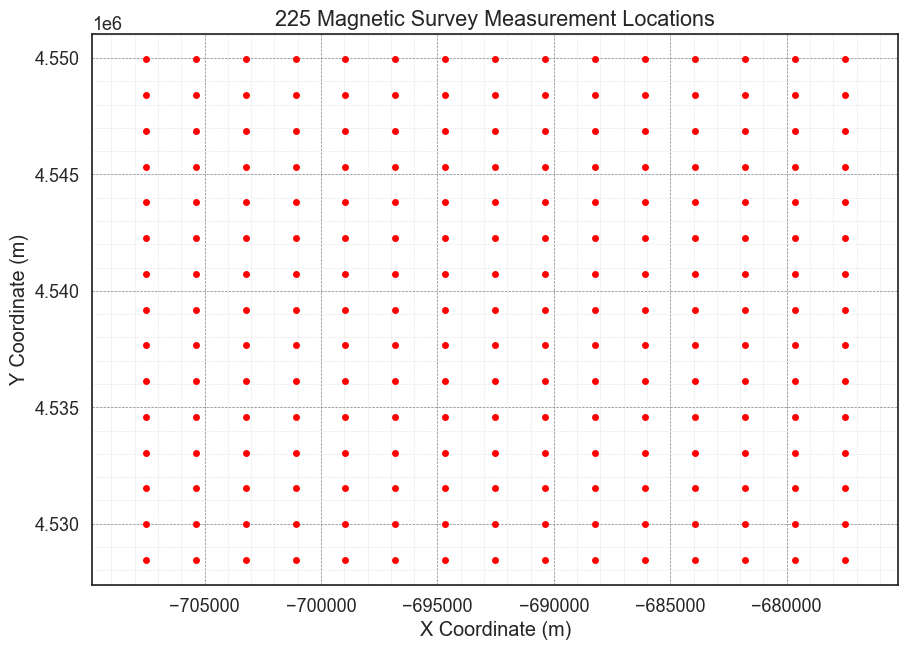

Active grids: GridTypes.NONE|CENTERED|TOPOGRAPHY|DENSE


In [4]:
# Creating measurement devices for magnetic survey - using same grid as gravity
mag_res = 15
X_mag = np.linspace(min_x, max_x, mag_res)
Y_mag = np.linspace(min_y, max_y, mag_res)
Z_mag = max_z
xyz_mag = np.meshgrid(X_mag, Y_mag, Z_mag)
xy_ravel_mag = np.vstack(list(map(np.ravel, xyz_mag))).T

plt.plot(xy_ravel_mag[:,0], xy_ravel_mag[:,1], 'o', color='red', markersize=5)
plt.grid(which='major', color='grey', linestyle='--', linewidth=0.5)
plt.minorticks_on()
plt.grid(which='minor', color='lightgrey', linestyle=':', linewidth=0.5)
plt.xlabel('X Coordinate (m)')
plt.ylabel('Y Coordinate (m)')
plt.title(f'{len(xy_ravel_mag)} Magnetic Survey Measurement Locations')
plt.axis('equal')
plt.show()

# Creating centred grids around the measurement devices for magnetic calculation
gp.set_centered_grid(
    grid=plutonite_geo_model.grid,
    centers=xy_ravel_mag,
    resolution=np.array([10, 10, 15]),
    radius=np.array([1000, 1000, 1000])
)

plutonite_geo_model.grid.centered_grid.kernel_grid_centers;

Assigning Susceptibility Values

In [ ]:
# Import the NumpyGraphPro class
import sys
import os
sys.path.append(r'c:\Users\mrcon\Downloads')
from numpy_graph_pro import NumpyGraphPro

# Assign magnetic susceptibilities to voxels

# 1. Get the formation IDs for the model
plutonite_lith_block = plutonite_geo_model.solutions.raw_arrays.lith_block
plutonite_lith_block_reshaped = plutonite_lith_block.reshape(64,64,64)

# 2. Get the coordinates of these voxels
voxel_coords = plutonite_geo_model.grid.regular_grid.values
voxel_coords_reshaped = voxel_coords.reshape(64, 64, 64, 3)

# 3. Flip Y coordinate
y_min, y_max = np.min(voxel_coords[:, 1]), np.max(voxel_coords[:, 1])
voxel_coords_flipped = voxel_coords.copy()
voxel_coords_flipped[:, 1] = y_max - (voxel_coords[:, 1] - y_min)

# 2. Identify the formation ID of the Plutonite
plutonite_id = 1

# 3. Create a boolean mask for plutonite voxels
plutonite_mask = plutonite_lith_block_reshaped == plutonite_id

# 4. Create a susceptibility array
susceptibility_array = np.full(plutonite_lith_block_reshaped.shape, 0.01)  # Default susceptibility for non-plutonite voxels
susceptibility_array[plutonite_mask] = 0.05  # Higher susceptibility for plutonite voxels
susceptibility_array_flat = susceptibility_array.flatten()

print(f"Susceptibility array shape: {susceptibility_array_flat.shape}")
print(f"Number of plutonite voxels: {np.sum(plutonite_mask)}")
print(f"Susceptibility range: {np.min(susceptibility_array_flat):.3f} to {np.max(susceptibility_array_flat):.3f}")

# Find which formations are present in each voxel of the geological model
# 1 = Plutonites
# 2 = Basement

Forward Modelling

In [ ]:
np.save("your_susceptibility.npy", susceptibility_array)

In [ ]:
voxel_centers = voxel_coords_flipped
voxel_sizes = np.array([plutonite_geo_model.grid.regular_grid.dx,
                         plutonite_geo_model.grid.regular_grid.dy,
                         plutonite_geo_model.grid.regular_grid.dz])
measurement_points = xy_ravel_mag

In [ ]:
from forward_modelling_magnetics_python import NumpyMagneticsForwardModeling


# Method 1: Manual cutoff
mag_engine = NumpyMagneticsForwardModeling(cutoff_distance=5000.0)
mag_engine.set_magnetic_parameters(B_ext=50e-6, incl=60.0, decl=1.0)
anomaly = mag_engine.load_and_process_model(
    "your_susceptibility.npy", 
    voxel_centers, 
    voxel_sizes, 
    measurement_points
)

In [ ]:
np.shape(anomaly)
copy = anomaly.copy()
copy = copy.reshape((mag_res, mag_res))

In [ ]:
plt.hist(anomaly)
# filter the anomaly -4000 above and below 4000

In [ ]:
np.shape(copy)

In [ ]:
plt.imshow(copy, cmap='viridis')
plt.colorbar(label='Magnetic Anomaly (T)')

In [ ]:
np.shape(anomaly)

In [ ]:
np.shape(susceptibility_3d), np.shape(voxel_centers), np.shape(voxel_sizes), np.shape(measurement_points)

In [5]:
import numpy as np
from forward_modelling_magnetics_python import NumpyMagneticsForwardModeling, create_example_model

# Create example data
susceptibility_3d, voxel_centers, voxel_sizes, measurement_points = create_example_model()

# Initialize the engine with 5km cutoff
mag_engine = NumpyMagneticsForwardModeling(cutoff_distance=5000.0)

# Set magnetic field parameters
mag_engine.set_magnetic_parameters(B_ext=50e-6, incl=60.0, decl=1.0)

# Save and process the model
np.save("test_susceptibility.npy", susceptibility_3d)
results = mag_engine.load_and_process_model(
    "test_susceptibility.npy", 
    voxel_centers, 
    voxel_sizes, 
    measurement_points
)

print(f"Results: {results}")

Creating example 3D susceptibility model...
Loading susceptibility model from test_susceptibility.npy
Loaded susceptibility model with shape: (20, 20, 15)
Processing 225 measurement points with 6000 voxels
Computing volume integrals for 6000 voxels and 225 measurements...
Using distance cutoff: 5.0 km
Pre-computing active voxels within cutoff distance...
  Measurement point 1: 6000/6000 active voxels (100.0%)
Total active voxel-measurement pairs: 1350000 (vs 1350000 without cutoff)
Computational reduction: 0.0%
Processing measurements 1 to 225 of 225
Volume integrals computed in 1.14 seconds
Computing magnetic forward modeling...
Using compact format with distance cutoff...
Processing 1350000 active voxel-measurement pairs
Volume integrals computed in 1.14 seconds
Computing magnetic forward modeling...
Using compact format with distance cutoff...
Processing 1350000 active voxel-measurement pairs
Magnetic anomaly computed: -807.25 to 233.19 nT
Magnetic forward modeling completed in 0.31

Visualizing magnetic forward modeling results...
Results shape: (225,)
Measurement points shape: (225, 3)
Grid size: 15x15


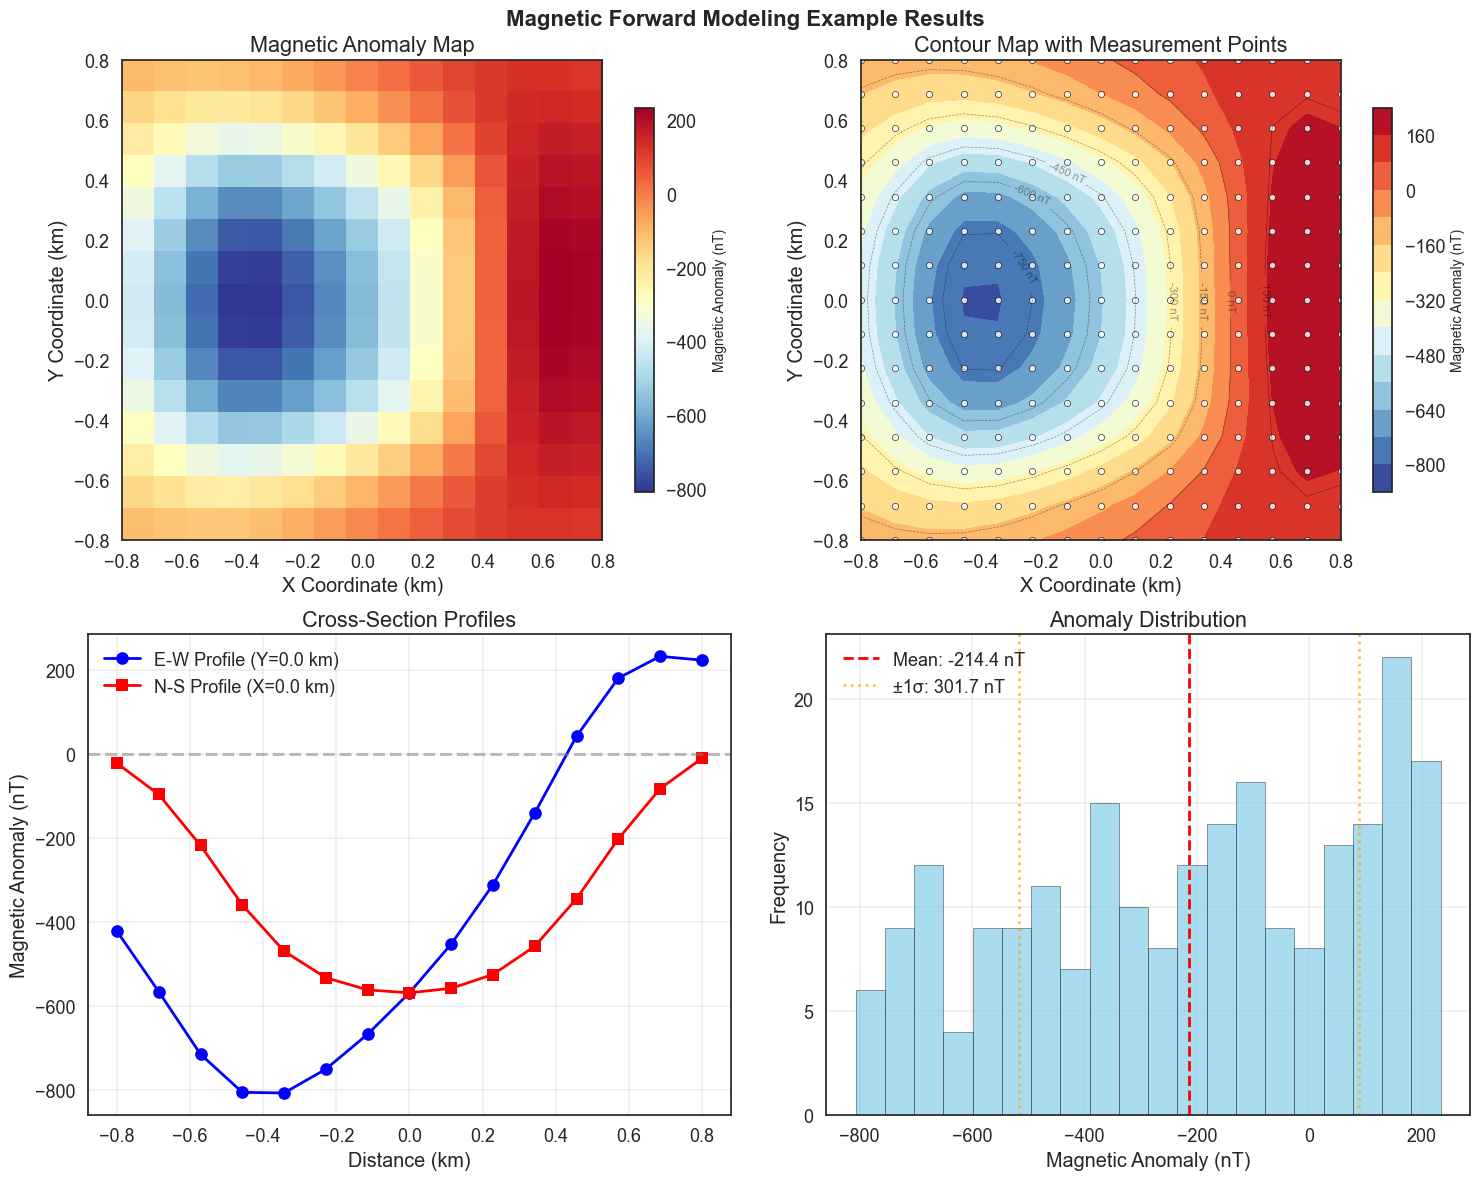


EXAMPLE RESULTS ANALYSIS
Measurement Configuration:
  Grid size: 15×15 points
  Survey area: 1.6 × 1.6 km²
  Elevation: 350 m

Magnetic Anomaly Statistics:
  Range: -807.25 to 233.19 nT
  Mean: -214.41 nT
  Standard deviation: 301.72 nT
  Peak-to-peak: 1040.43 nT

Model Information:
  Susceptibility contrast: High-susceptibility body vs background
  Magnetic field: 50.0 µT
  Inclination: 60.0°
  Declination: 1.0°

🎯 Example successfully demonstrates magnetic forward modeling!
📊 Visualizations show realistic magnetic anomaly patterns


In [6]:
# Visualize the Example Results

print("Visualizing magnetic forward modeling results...")
print(f"Results shape: {results.shape}")
print(f"Measurement points shape: {measurement_points.shape}")

# Since the example creates a 15x15 measurement grid
grid_size = int(np.sqrt(len(results)))
print(f"Grid size: {grid_size}x{grid_size}")

# Reshape results to 2D grid for visualization
if len(results) == grid_size * grid_size:
    results_2d = results.reshape(grid_size, grid_size)
    
    # Create comprehensive visualization
    # Create comprehensive visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Magnetic Forward Modeling Example Results', fontsize=16, fontweight='bold')
    
    # Extract coordinate ranges from measurement points
    x_coords = measurement_points[:, 0]
    y_coords = measurement_points[:, 1]
    z_coords = measurement_points[:, 2]
    
    x_range = [np.min(x_coords), np.max(x_coords)]
    y_range = [np.min(y_coords), np.max(y_coords)]
    
    # Plot 1: Magnetic anomaly map (imshow)
    im1 = ax1.imshow(results_2d, extent=[x_range[0]/1000, x_range[1]/1000, 
                                        y_range[0]/1000, y_range[1]/1000], 
                     cmap='RdYlBu_r', origin='lower', interpolation='nearest')
    cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.8)
    cbar1.set_label('Magnetic Anomaly (nT)', fontsize=10)
    ax1.set_xlabel('X Coordinate (km)')
    ax1.set_ylabel('Y Coordinate (km)')
    ax1.set_title('Magnetic Anomaly Map')
    ax1.set_aspect('equal')
    
    # Plot 2: Contour plot with measurement points
    X_mesh = np.linspace(x_range[0]/1000, x_range[1]/1000, grid_size)
    Y_mesh = np.linspace(y_range[0]/1000, y_range[1]/1000, grid_size)
    X_grid, Y_grid = np.meshgrid(X_mesh, Y_mesh)
    
    contour = ax2.contourf(X_grid, Y_grid, results_2d, levels=15, cmap='RdYlBu_r')
    contour_lines = ax2.contour(X_grid, Y_grid, results_2d, levels=8, colors='black', alpha=0.4, linewidths=0.5)
    ax2.clabel(contour_lines, inline=True, fontsize=8, fmt='%.0f nT')
    
    # Add measurement points
    ax2.scatter(x_coords/1000, y_coords/1000, c='white', s=20, alpha=0.8, 
               edgecolors='black', linewidths=0.5)
    
    cbar2 = plt.colorbar(contour, ax=ax2, shrink=0.8)
    cbar2.set_label('Magnetic Anomaly (nT)', fontsize=10)
    ax2.set_xlabel('X Coordinate (km)')
    ax2.set_ylabel('Y Coordinate (km)')
    ax2.set_title('Contour Map with Measurement Points')
    ax2.set_aspect('equal')
    
    # Plot 3: Cross-section profiles
    mid_row = grid_size // 2
    mid_col = grid_size // 2
    
    # E-W profile (constant Y)
    ax3.plot(X_mesh, results_2d[mid_row, :], 'b-', linewidth=2, marker='o', 
             label=f'E-W Profile (Y={Y_mesh[mid_row]:.1f} km)')
    
    # N-S profile (constant X) 
    ax3.plot(Y_mesh, results_2d[:, mid_col], 'r-', linewidth=2, marker='s',
             label=f'N-S Profile (X={X_mesh[mid_col]:.1f} km)')
    
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax3.set_xlabel('Distance (km)')
    ax3.set_ylabel('Magnetic Anomaly (nT)')
    ax3.set_title('Cross-Section Profiles')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # Plot 4: Statistics and histogram
    ax4.hist(results.flatten(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax4.set_xlabel('Magnetic Anomaly (nT)')
    ax4.set_ylabel('Frequency')
    ax4.set_title('Anomaly Distribution')
    ax4.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(results)
    std_val = np.std(results)
    ax4.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f} nT')
    ax4.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=2, alpha=0.7)
    ax4.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=2, alpha=0.7, 
               label=f'±1σ: {std_val:.1f} nT')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

# Print detailed statistics
print(f"\n" + "="*50)
print("EXAMPLE RESULTS ANALYSIS")
print("="*50)
print(f"Measurement Configuration:")
print(f"  Grid size: {grid_size}×{grid_size} points")
print(f"  Survey area: {(x_range[1]-x_range[0])/1000:.1f} × {(y_range[1]-y_range[0])/1000:.1f} km²")
print(f"  Elevation: {np.mean(z_coords):.0f} m")

print(f"\nMagnetic Anomaly Statistics:")
print(f"  Range: {np.min(results):.2f} to {np.max(results):.2f} nT")
print(f"  Mean: {np.mean(results):.2f} nT")
print(f"  Standard deviation: {np.std(results):.2f} nT")
print(f"  Peak-to-peak: {np.max(results) - np.min(results):.2f} nT")

print(f"\nModel Information:")
print(f"  Susceptibility contrast: High-susceptibility body vs background")
print(f"  Magnetic field: {mag_engine.B_ext*1e6:.1f} µT")
print(f"  Inclination: {mag_engine.incl:.1f}°")
print(f"  Declination: {mag_engine.decl:.1f}°")

print(f"\n🎯 Example successfully demonstrates magnetic forward modeling!")
print(f"📊 Visualizations show realistic magnetic anomaly patterns")
print("="*50)